# AK-SYS basic example

Three-component AND-system example from Fauriat and Gayton (2014). AK-SYS fits one Gaussian-process surrogate per component and evaluates only the component that controls the system U-function at each added point.


In [1]:
import numpy as np
from ak_based_sampler import AK_SYS


def g1(u):
    return 8 * u[..., 1]**2 - 8 * u[..., 0]**2 + (u[..., 0]**2 + u[..., 1]**2)**2


def g2(u):
    return 2 * u[..., 0]**2 - 2 * u[..., 1]**2 - (u[..., 0]**2 + u[..., 1]**2)**2


def g3(u):
    return 8 * u[..., 1]**2 - 8 * u[..., 0]**2 - (u[..., 0]**2 + u[..., 1]**2)**2


In [2]:
sampler = AK_SYS(dim=2, LSFs=[g1, g2, g3], gate="AND")

sampler.set_parameters(
    n_initial_population=10_000,
    n_initial_DoEs=12,
    u_stop=2.0,
    cov_stop=0.05,
    max_iterations_u=100,
    max_iterations_cov=10,
)

pf = sampler(seed=1, verbose=True)
print(f"Estimated system failure probability: {pf:.6g}")
print(dict(sampler.result))


[AK-SYS] CoV 1/10, U 1/100: min U=4.83059e-05, pf=0.1943
[AK-SYS] CoV 1/10, U 2/100: min U=1.84293e-05, pf=0.2019
[AK-SYS] CoV 1/10, U 3/100: min U=0.000269267, pf=0.1796
[AK-SYS] CoV 1/10, U 4/100: min U=0.000362585, pf=0.1814
[AK-SYS] CoV 1/10, U 5/100: min U=0.000513346, pf=0.2054
[AK-SYS] CoV 1/10, U 6/100: min U=0.000220919, pf=0.2051
[AK-SYS] CoV 1/10, U 7/100: min U=0.000391669, pf=0.2068
[AK-SYS] CoV 1/10, U 8/100: min U=0.000747747, pf=0.1708
[AK-SYS] CoV 1/10, U 9/100: min U=6.46449e-06, pf=0.1778
[AK-SYS] CoV 1/10, U 10/100: min U=0.00350864, pf=0.182
[AK-SYS] CoV 1/10, U 11/100: min U=5.26123e-05, pf=0.1386
[AK-SYS] CoV 1/10, U 12/100: min U=0.00115567, pf=0.121
[AK-SYS] CoV 1/10, U 13/100: min U=0.0045455, pf=0.1328
[AK-SYS] CoV 1/10, U 14/100: min U=0.00268909, pf=0.1359
[AK-SYS] CoV 1/10, U 15/100: min U=0.00372406, pf=0.1464
[AK-SYS] CoV 1/10, U 16/100: min U=0.00620084, pf=0.1625
[AK-SYS] CoV 1/10, U 17/100: min U=0.00529499, pf=0.1619
[AK-SYS] CoV 1/10, U 18/100: min 

Estimated system failure probability: 0.1923
{'pf': 0.1923, 'n_called': (32, 37, 19), 'n_population': 10000, 'min_u_value': 2.4181394774675176, 'cov': 0.02049440901397338, 'gate': 'AND'}


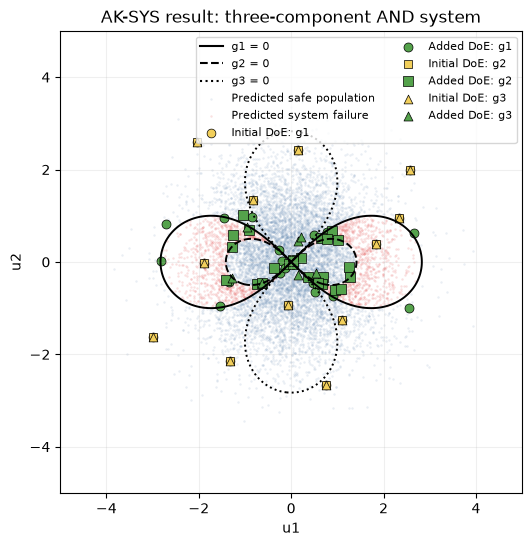

In [3]:
import matplotlib.pyplot as plt

population_u, component_g, component_sigma, system_g = sampler.train_data["population"]
initial_does = sampler.train_data["initial_DoE"]
added_does = sampler.train_data["DoE"]

grid = np.linspace(-5, 5, 350)
u1, u2 = np.meshgrid(grid, grid)
grid_points = np.stack([u1, u2], axis=-1)

fig, ax = plt.subplots(figsize=(7, 6))
for func, style, label in zip([g1, g2, g3], ["-", "--", ":"], ["g1 = 0", "g2 = 0", "g3 = 0"]):
    ax.contour(u1, u2, func(grid_points), levels=[0.0], colors="black", linestyles=style, linewidths=1.4)
    ax.plot([], [], color="black", linestyle=style, label=label)

failure_mask = system_g <= 0.0
ax.scatter(population_u[~failure_mask, 0], population_u[~failure_mask, 1], s=3, c="#4c78a8", alpha=0.12, linewidths=0, label="Predicted safe population")
ax.scatter(population_u[failure_mask, 0], population_u[failure_mask, 1], s=3, c="#e45756", alpha=0.18, linewidths=0, label="Predicted system failure")

markers = ["o", "s", "^"]
for i, ((initial_u, _), (added_u, _)) in enumerate(zip(initial_does, added_does)):
    ax.scatter(initial_u[:, 0], initial_u[:, 1], s=40, marker=markers[i], c="#f2cf5b", edgecolors="black", linewidths=0.5, label=f"Initial DoE: g{i + 1}")
    if len(added_u):
        ax.scatter(added_u[:, 0], added_u[:, 1], s=42, marker=markers[i], c="#54a24b", edgecolors="black", linewidths=0.5, label=f"Added DoE: g{i + 1}")

ax.set_title("AK-SYS result: three-component AND system")
ax.set_xlabel("u1")
ax.set_ylabel("u2")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", fontsize=8, ncols=2)
ax.grid(alpha=0.2)
plt.show()
